# Cloud Masking PlanetScope Hyperspectral Imagery

This notebook demonstrates how to download and load a PlanetScope hyperspectral (HYP) scene stored in HDF5 format, select the appropriate spectral bands, and generate a cloud mask with OmniCloudMask.

PlanetScope hyperspectral data contains hundreds of narrow spectral bands. OmniCloudMask only requires **Red, Green, and NIR** bands, so we pick the closest matching band indices from the hyperspectral cube.

**Extra dependencies:**
```
pip install h5py
```

In [1]:
from pathlib import Path
from urllib.request import urlretrieve

import h5py
import matplotlib.pyplot as plt
import numpy as np

from omnicloudmask import predict_from_array

## 1. Download a PlanetScope hyperspectral scene

Retrieve a sample HYP scene from the Planet open-data STAC bucket. The file is in HDF5 format and contains top-of-atmosphere radiance values across all hyperspectral bands.

In [2]:
sample_scene_url = "https://storage.googleapis.com/open-cogs/planet-stac/release1-basic-radiance/20250302_030003_92_4001_basic_radiance.h5"

In [3]:
scene_path = Path("PlanetScope data", sample_scene_url.split("/")[-1])
scene_path.parent.mkdir(parents=True, exist_ok=True)

In [4]:
urlretrieve(sample_scene_url, scene_path)

(PosixPath('PlanetScope data/20250302_030003_92_4001_basic_radiance.h5'),
 <http.client.HTTPMessage at 0x11e0d78f0>)

## 2. Load bands

Open the HDF5 file and read the full hyperspectral data cube. The array shape is `(bands, height, width)` with values in top-of-atmosphere radiance units.

In [5]:
file = h5py.File(scene_path, "r")
array = np.array(file["HDFEOS"]["SWATHS"]["HYP"]["Data Fields"]["toa_radiance"][:])

Select the hyperspectral band indices that correspond to Red (~660 nm), Green (~550 nm), Blue (~470 nm), and NIR (~850 nm). These index values are specific to the PlanetScope HYP sensor's spectral sampling; adjust them if your scene uses a different wavelength calibration.

In [6]:
red_index = 58  # ~660 nm
green_index = 37  # ~550 nm
blue_index = 23  # ~470 nm
nir_index = 98  # ~850 nm

Extract the Red, Green, and NIR bands for OmniCloudMask inference, and the Red, Green, Blue bands for true-colour display.

In [7]:
rgnir = array[[red_index, green_index, nir_index]]
rgb = array[[red_index, green_index, blue_index]]

## 3. Run OmniCloudMask

Pass the Red, Green, NIR array to `predict_from_array`. The output has classes 0=clear, 1=thick cloud, 2=thin cloud, 3=cloud shadow.

In [8]:
mask = predict_from_array(rgnir)

/Users/nick/Documents/Work Code/OmniCloudMask/omnicloudmask/cloud_mask.py:274: UserWarning: Patch size too large, reducing to 607 and overlap to 300.
  patch_overlap, patch_size = check_patch_size(


## 4. Visualise

Scale the RGB bands by dividing by 300 (approximate full-scale radiance) to produce a displayable true-colour image, then show the standard 3-panel visualisation.

In [9]:
rgb_display = np.clip(rgb.transpose(1, 2, 0) / 300, 0, 1)

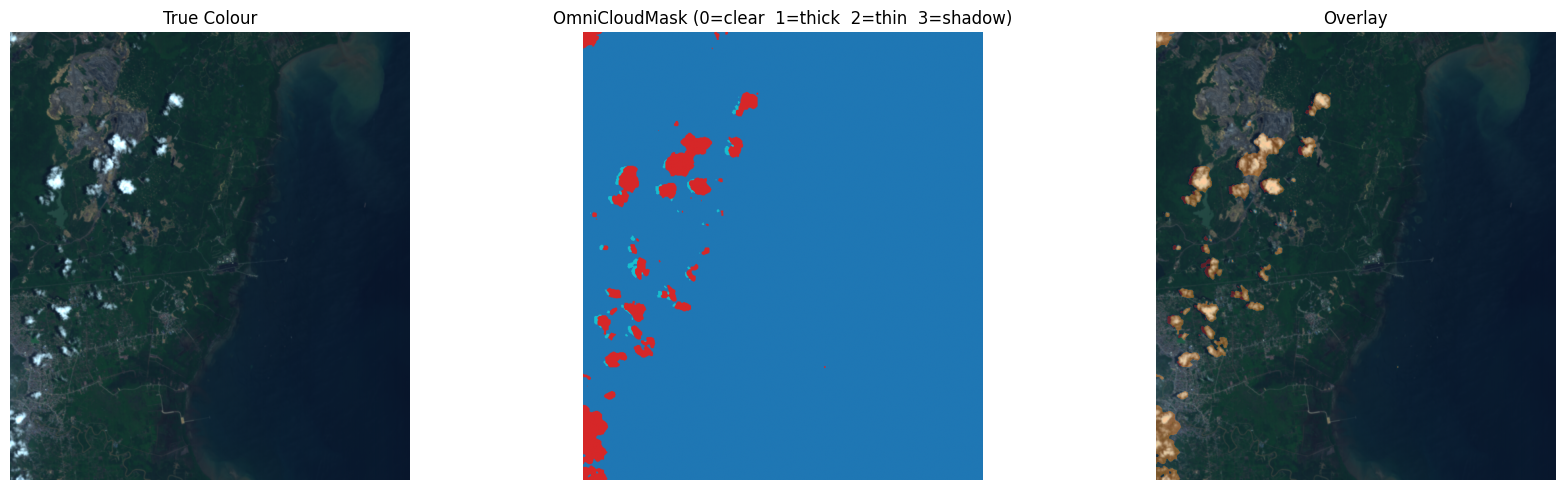

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel 1: true colour
axes[0].imshow(rgb_display)
axes[0].set_title("True Colour")
axes[0].axis("off")

# Panel 2: cloud mask
axes[1].imshow(mask.squeeze(), cmap="tab10", vmin=0, vmax=3)
axes[1].set_title("OmniCloudMask (0=clear  1=thick  2=thin  3=shadow)")
axes[1].axis("off")

# Panel 3: overlay — clear pixels transparent, others at 40% opacity
tab10 = plt.get_cmap("tab10")
mask_sq = mask.squeeze()
rgba = np.zeros((*mask_sq.shape, 4), dtype=float)
for cls in range(4):
    colour = tab10(cls / 9)
    where = mask_sq == cls
    rgba[where, :3] = colour[:3]
    rgba[where, 3] = 0.0 if cls == 0 else 0.4

axes[2].imshow(rgb_display)
axes[2].imshow(rgba)
axes[2].set_title("Overlay")
axes[2].axis("off")

plt.tight_layout()
plt.show()

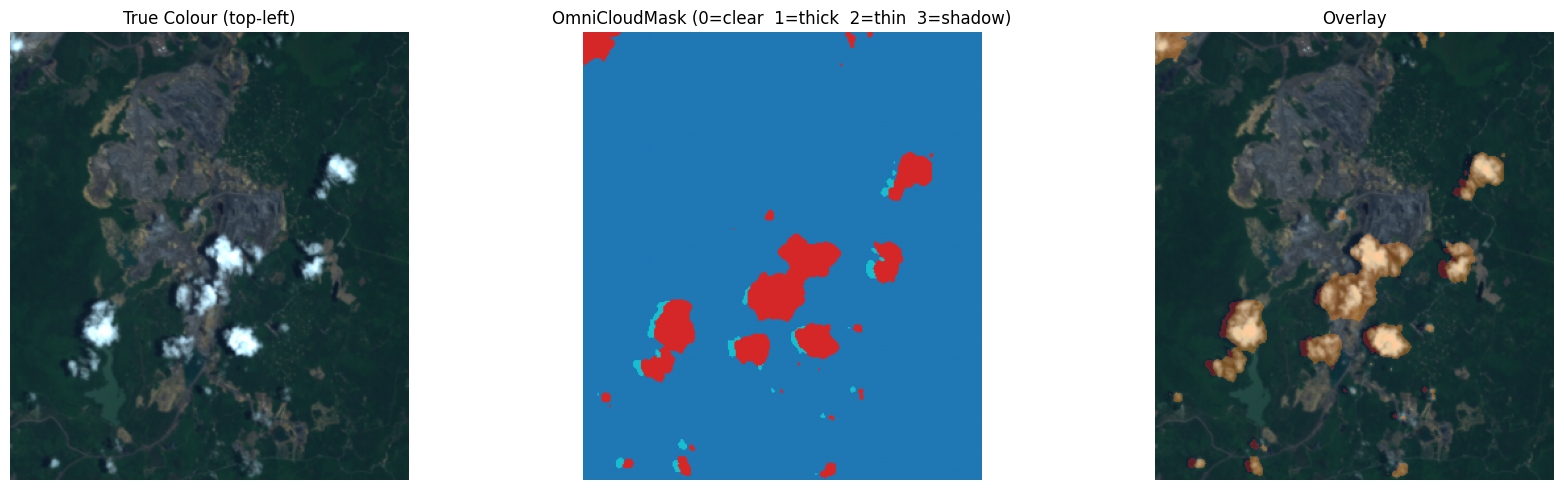

In [11]:
h, w = mask_sq.shape
rs, re, cs, ce = 0, h // 2, 0, w // 2

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].imshow(rgb_display[rs:re, cs:ce])
axes[0].set_title("True Colour (top-left)")
axes[0].axis("off")
axes[1].imshow(mask_sq[rs:re, cs:ce], cmap="tab10", vmin=0, vmax=3)
axes[1].set_title("OmniCloudMask (0=clear  1=thick  2=thin  3=shadow)")
axes[1].axis("off")
axes[2].imshow(rgb_display[rs:re, cs:ce])
axes[2].imshow(rgba[rs:re, cs:ce])
axes[2].set_title("Overlay")
axes[2].axis("off")
plt.tight_layout()
plt.show()